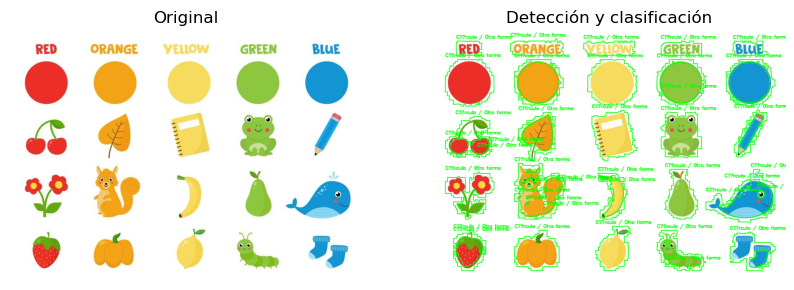

[{'clasificacion': 'Círculo / Otra forma', 'vertices': 21, 'area': 1469, 'hu_moments': [0.28826678751677437, 0.6546538735172732, 2.1018443542466874, 2.2014146217855193, 4.353264609875097, 2.5394268513494302, -5.849817318906159]}, {'clasificacion': 'Círculo / Otra forma', 'vertices': 20, 'area': 1175, 'hu_moments': [0.4604142076283486, 1.1623163891055892, 2.07978757833613, 2.922622573131593, -5.621660587660171, -3.738638937735211, -5.535513118430543]}, {'clasificacion': 'Círculo / Otra forma', 'vertices': 21, 'area': 14202, 'hu_moments': [0.6350076876756825, 2.499991504456992, 3.4629854322708287, 3.167091589713698, 7.155967613993017, 4.465848868720295, -6.49210588723867]}, {'clasificacion': 'Círculo / Otra forma', 'vertices': 26, 'area': 7775, 'hu_moments': [0.1837973630829697, 0.6783748242187434, 0.9484602711653253, 1.2882918865594164, 2.411632791616165, 1.6279481804013787, -3.2295707768337296]}, {'clasificacion': 'Círculo / Otra forma', 'vertices': 20, 'area': 20634, 'hu_moments': [0.

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def clasificar_por_vertices(approx):
    vertices = len(approx)
    if vertices == 3:
        return "Triángulo"
    elif vertices == 4:
        return "Cuadrado / Rectángulo"
    elif vertices == 5:
        return "Pentágono"
    elif vertices == 6:
        return "Hexágono"
    else:
        return "Círculo / Otra forma"

def detectar_figuras_y_momentos(ruta_imagen):
    img = cv2.imread(ruta_imagen)
    if img is None:
        raise FileNotFoundError(f"No se encontró la imagen: {ruta_imagen}")

    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Mejorar detección con equalización de histograma
    gris = cv2.equalizeHist(gris)
    
    # Aplicar Gaussian Blur para suavizar
    gris = cv2.GaussianBlur(gris, (5, 5), 0)
    
    # Usar threshold adaptativo para mejor detección
    binaria = cv2.adaptiveThreshold(gris, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
    
    # Aplicar operaciones morfológicas para cerrar pequeños huecos
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    binaria = cv2.morphologyEx(binaria, cv2.MORPH_CLOSE, kernel)
    binaria = cv2.morphologyEx(binaria, cv2.MORPH_OPEN, kernel)

    contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    salida = img.copy()
    resultados = []

    for contorno in contornos:
        area = cv2.contourArea(contorno)
        if area < 100:  # Area mínima reducida
            continue

        perimetro = cv2.arcLength(contorno, True)
        approx = cv2.approxPolyDP(contorno, 0.01 * perimetro, True)  # Aproximación más fina
        clasificacion = clasificar_por_vertices(approx)

        momentos = cv2.moments(contorno)
        hu = cv2.HuMoments(momentos).flatten()
        hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)

        cv2.drawContours(salida, [contorno], -1, (0, 255, 0), 2)
        x, y, w, h = cv2.boundingRect(contorno)
        cv2.putText(salida, clasificacion, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        resultados.append({
            "clasificacion": clasificacion,
            "vertices": len(approx),
            "area": int(area),
            "hu_moments": hu_log.tolist()
        })

    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Detección y clasificación")
    plt.imshow(cv2.cvtColor(salida, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    return resultados


resultados = detectar_figuras_y_momentos("colores.jpg")
print(resultados)